<a href="https://colab.research.google.com/github/nishant-sru/ML_LAB/blob/main/ML_Lab_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Understanding and Loading the Dataset
##Objective:
To understand and load the salary dataset for linear regression.
Tasks:
1. Download the dataset from Kaggle.
2. Load the dataset using Pandas.
3. Display first and last five rows.
4. Identify input and output variables.

In [5]:
import pandas as pd

# --- Step 1: Load the dataset using Pandas ---
# IMPORTANT: Replace 'path/to/your/dataset.csv' with the actual path to your dataset.
# If your dataset is not a CSV, use the appropriate pandas read function (e.g., pd.read_excel, pd.read_json).
try:
    df = pd.read_csv('/content/Salary_dataset.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Dataset not found. Please update the path to your dataset.")

#Displaying the First Five Rows
print("\nFirst five rows of the dataset:")
print(df.head())

#Displaying the Last Five Rows
print("\nLast five rows of the dataset:")
print(df.tail())

print("\nColumns in the dataset (potential variables):")
print(df.columns.tolist())

print("\nGuidance on identifying input and output variables:")
print("Input variables (features) are the columns you use to predict something.")
print("Output variable (target) is the column you are trying to predict.")
print("You need to decide which columns are inputs and which is the output based on your specific analysis goal.")
print("For example, if 'target' is your output, then 'feature1' and 'feature2' would be inputs.")


Dataset loaded successfully.

First five rows of the dataset:
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0

Last five rows of the dataset:
    Unnamed: 0  YearsExperience    Salary
25          25              9.1  105583.0
26          26              9.6  116970.0
27          27              9.7  112636.0
28          28             10.4  122392.0
29          29             10.6  121873.0

Columns in the dataset (potential variables):
['Unnamed: 0', 'YearsExperience', 'Salary']

Guidance on identifying input and output variables:
Input variables (features) are the columns you use to predict something.
Output variable (target) is the column you are trying to predict.
You need to decide which columns are inputs and which is the output based on your specific analysis goal.
For example, if 'target' 

#Data Preprocessing using NumPy
##Objective:
To preprocess data and convert it into NumPy arrays.
Tasks:
1. Separate independent and dependent variables.
2. Convert data into NumPy arrays.
3. Reshape arrays for computation.
4. Normalize the data if required.

In [14]:
import numpy as np

# The 'Unnamed: 0' column was likely dropped in a previous step, so this line is removed to prevent KeyError.
# df = df.drop('Unnamed: 0', axis=1) # Original line causing error
print("Assuming 'Unnamed: 0' column was previously dropped or did not exist. Remaining columns:")
print(df.columns.tolist())

# 2. Create a new variable X containing the 'YearsExperience' column
X = df[['YearsExperience']]
print("\nIndependent variable (X - YearsExperience) head:")
print(X.head())

# 3. Create a new variable y containing the 'Salary' column
y = df['Salary']
print("\nDependent variable (y - Salary) head:")
print(y.head())


print()
# Convert X (YearsExperience) to a NumPy array
X_numpy = X.to_numpy()
print("X (independent variable) converted to NumPy array. Shape:", X_numpy.shape)
print("First 5 elements of X_numpy:\n", X_numpy[:5])

# Convert y (Salary) to a NumPy array
y_numpy = y.to_numpy()
print("\ny (dependent variable) converted to NumPy array. Shape:", y_numpy.shape)
print("First 5 elements of y_numpy:\n", y_numpy[:5])

print()

print("Original shape of X_numpy:", X_numpy.shape)
print("Original shape of y_numpy:", y_numpy.shape)


print()
# Reshape X_numpy if it's 1D (e.g., (n_samples,) to (n_samples, 1))
# X_numpy is currently (30, 1), which is already 2D, so no reshaping is needed for this dataset.
if X_numpy.ndim == 1:
    X_numpy = X_numpy.reshape(-1, 1)
    print("X_numpy was reshaped to:", X_numpy.shape)
else:
    print("X_numpy is already 2D (samples, features). No reshaping needed.")



# For y_numpy, it is typically 1D for most scikit-learn models. If a specific model requires 2D, it would be reshaped to (-1, 1).
# Currently, y_numpy is (30,), which is a 1D array and suitable for most models.
# If we needed to reshape to (n_samples, 1) for specific model requirements, we would do:
# y_numpy_2d = y_numpy.reshape(-1, 1)

print("Final shape of X_numpy:", X_numpy.shape)
print("Final shape of y_numpy:", y_numpy.shape)



from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler for X
x_scaler = StandardScaler()
# Fit and transform X_numpy
X_scaled = x_scaler.fit_transform(X_numpy)

print("Original X_numpy (YearsExperience) - Mean: {:.2f}, Std: {:.2f}".format(X_numpy.mean(), X_numpy.std()))
print("Scaled X_numpy (YearsExperience) - Mean: {:.2f}, Std: {:.2f}".format(X_scaled.mean(), X_scaled.std()))
print("First 5 elements of X_scaled:\n", X_scaled[:5])
print("Shape of X_scaled:", X_scaled.shape)

# Initialize StandardScaler for y
y_scaler = StandardScaler()
# Reshape y_numpy to 2D for scaling (StandardScaler expects 2D array)
y_numpy_reshaped = y_numpy.reshape(-1, 1)
# Fit and transform y_numpy
y_scaled = y_scaler.fit_transform(y_numpy_reshaped)

print("\nOriginal y_numpy (Salary) - Mean: {:.2f}, Std: {:.2f}".format(y_numpy.mean(), y_numpy.std()))
print("Scaled y_numpy (Salary) - Mean: {:.2f}, Std: {:.2f}".format(y_scaled.mean(), y_scaled.std()))
print("First 5 elements of y_scaled:\n", y_scaled[:5])
print("Shape of y_scaled:", y_scaled.shape)


Assuming 'Unnamed: 0' column was previously dropped or did not exist. Remaining columns:
['YearsExperience', 'Salary']

Independent variable (X - YearsExperience) head:
   YearsExperience
0              1.2
1              1.4
2              1.6
3              2.1
4              2.3

Dependent variable (y - Salary) head:
0    39344.0
1    46206.0
2    37732.0
3    43526.0
4    39892.0
Name: Salary, dtype: float64

X (independent variable) converted to NumPy array. Shape: (30, 1)
First 5 elements of X_numpy:
 [[1.2]
 [1.4]
 [1.6]
 [2.1]
 [2.3]]

y (dependent variable) converted to NumPy array. Shape: (30,)
First 5 elements of y_numpy:
 [39344. 46206. 37732. 43526. 39892.]

Original shape of X_numpy: (30, 1)
Original shape of y_numpy: (30,)

X_numpy is already 2D (samples, features). No reshaping needed.
Final shape of X_numpy: (30, 1)
Final shape of y_numpy: (30,)
Original X_numpy (YearsExperience) - Mean: 5.41, Std: 2.79
Scaled X_numpy (YearsExperience) - Mean: 0.00, Std: 1.00
First 5 e

#Implementing Linear Regression Model from Scratch
##Objective:
To implement linear regression using mathematical equations.
Tasks:
1. Initialize slope and intercept.
2. Implement prediction equation.
3. Implement cost function (MSE).
4. Compute cost for given parameters.


## Initialize Parameters
Initialize the slope (m) and intercept (b) for the linear regression model with arbitrary starting values (e.g., 0).


In [15]:
m = 0
b = 0
print(f"Initial slope (m): {m}")
print(f"Initial intercept (b): {b}")

Initial slope (m): 0
Initial intercept (b): 0


## Define Prediction Equation
Implement a function that calculates the predicted values (y_pred) given the input features (X), slope (m), and intercept (b) using the equation: y_pred = m * X + b.


In [16]:
def predict(X, m, b):
    """
    Calculates the predicted values (y_pred) for a linear regression model.

    Args:
        X (numpy.ndarray): The input features (independent variable).
        m (float): The slope of the regression line.
        b (float): The intercept of the regression line.

    Returns:
        numpy.ndarray: The predicted values (y_pred).
    """
    y_pred = m * X + b
    return y_pred

# Call the predict function with X_scaled, m, and b
y_pred = predict(X_scaled, m, b)

print("Predicted values (y_pred) using initial parameters:")
print(f"First 5 elements of y_pred:\n{y_pred[:5]}")
print(f"Shape of y_pred: {y_pred.shape}")

Predicted values (y_pred) using initial parameters:
First 5 elements of y_pred:
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]
Shape of y_pred: (30, 1)


## Implement Cost Function (MSE)
&
## Compute Initial Cost


In [17]:
def calculate_mse(y_true, y_pred):
    """
    Calculates the Mean Squared Error (MSE).

    Args:
        y_true (numpy.ndarray): The actual target values.
        y_pred (numpy.ndarray): The predicted target values.

    Returns:
        float: The Mean Squared Error.
    """
    n = len(y_true)
    # Ensure y_true and y_pred have the same shape for element-wise subtraction
    # If y_pred is (30,1) and y_true is (30,1), this works fine.
    # If y_true is (30,) and y_pred is (30,1), reshape y_true to (30,1).
    if y_true.shape != y_pred.shape:
        if y_true.ndim == 1:
            y_true = y_true.reshape(-1, 1)
        elif y_pred.ndim == 1:
            y_pred = y_pred.reshape(-1, 1)

    squared_errors = (y_true - y_pred)**2
    mse = np.mean(squared_errors)
    return mse

# Calculate the initial MSE using y_scaled and y_pred
initial_mse = calculate_mse(y_scaled, y_pred)
print(f"Initial Mean Squared Error (MSE) with m={m}, b={b}: {initial_mse:.4f}")

Initial Mean Squared Error (MSE) with m=0, b=0: 1.0000


# Model Training using Gradient Descent
##Objective:
To train the linear regression model using gradient descent.
Tasks:
1. Define learning rate and epochs.
2. Update slope and intercept iteratively.
3. Monitor cost reduction.
4. Store final model parameters.

# Task
Implement a gradient descent algorithm to train the linear regression model, including defining the learning rate and number of epochs, iteratively updating the slope (m) and intercept (b) based on calculated gradients, monitoring and storing the Mean Squared Error (MSE) at regular intervals, and finally storing the optimized model parameters (m and b).

## Define Learning Rate and Epochs




In [18]:
alpha = 0.01  # Learning rate
epochs = 1000 # Number of iterations

print(f"Learning rate (alpha): {alpha}")
print(f"Number of epochs: {epochs}")

Learning rate (alpha): 0.01
Number of epochs: 1000


## Update Slope and Intercept Iteratively



In [19]:
mse_history = []
m_history = []
b_history = []

n = len(y_scaled) # Number of samples

for epoch in range(epochs):
    # 1. Calculate predictions
    y_pred = predict(X_scaled, m, b)

    # 2. Calculate gradients
    # Reshape y_scaled to be consistent with y_pred if necessary
    if y_scaled.shape != y_pred.shape and y_scaled.ndim == 1:
        y_scaled_reshaped = y_scaled.reshape(-1, 1)
    else:
        y_scaled_reshaped = y_scaled

    dm = (2/n) * np.sum((y_pred - y_scaled_reshaped) * X_scaled)
    db = (2/n) * np.sum(y_pred - y_scaled_reshaped)

    # 3. Update parameters
    m = m - alpha * dm
    b = b - alpha * db

    # 4. Calculate and store MSE
    current_mse = calculate_mse(y_scaled_reshaped, y_pred)
    mse_history.append(current_mse)
    m_history.append(m)
    b_history.append(b)

    # 5. Print progress
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, MSE: {current_mse:.4f}, m: {m:.4f}, b: {b:.4f}")

print("\nGradient Descent training completed.")
print(f"Final m: {m:.4f}")
print(f"Final b: {b:.4f}")
print(f"Final MSE: {mse_history[-1]:.4f}")

Epoch 100/1000, MSE: 0.0606, m: 0.8485, b: -0.0000
Epoch 200/1000, MSE: 0.0434, m: 0.9610, b: -0.0000
Epoch 300/1000, MSE: 0.0430, m: 0.9760, b: -0.0000
Epoch 400/1000, MSE: 0.0430, m: 0.9779, b: -0.0000
Epoch 500/1000, MSE: 0.0430, m: 0.9782, b: -0.0000
Epoch 600/1000, MSE: 0.0430, m: 0.9782, b: -0.0000
Epoch 700/1000, MSE: 0.0430, m: 0.9782, b: -0.0000
Epoch 800/1000, MSE: 0.0430, m: 0.9782, b: -0.0000
Epoch 900/1000, MSE: 0.0430, m: 0.9782, b: -0.0000
Epoch 1000/1000, MSE: 0.0430, m: 0.9782, b: -0.0000

Gradient Descent training completed.
Final m: 0.9782
Final b: -0.0000
Final MSE: 0.0430


## Store Final Model Parameters



##Objective:
To evaluate model performance and visualize results.
Tasks:
1. Predict salary using trained model.
2. Calculate Mean Squared Error.
3. Plot regression line with data points.
4. Interpret the results.

## Predict Salary using Trained Model




In [20]:
y_pred_final_scaled = predict(X_scaled, m, b)
print("Predicted scaled salaries (y_pred_final_scaled) using optimized parameters:")
print(f"First 5 elements of y_pred_final_scaled:\n{y_pred_final_scaled[:5]}")
print(f"Shape of y_pred_final_scaled: {y_pred_final_scaled.shape}")

Predicted scaled salaries (y_pred_final_scaled) using optimized parameters:
First 5 elements of y_pred_final_scaled:
[[-1.47719663]
 [-1.40707653]
 [-1.33695644]
 [-1.16165621]
 [-1.09153611]]
Shape of y_pred_final_scaled: (30, 1)


## Calculate Final Mean Squared Error



In [21]:
final_mse = calculate_mse(y_scaled, y_pred_final_scaled)
print(f"Final Mean Squared Error (MSE) after gradient descent: {final_mse:.4f}")

Final Mean Squared Error (MSE) after gradient descent: 0.0430


## Plot Regression Line with Data Points



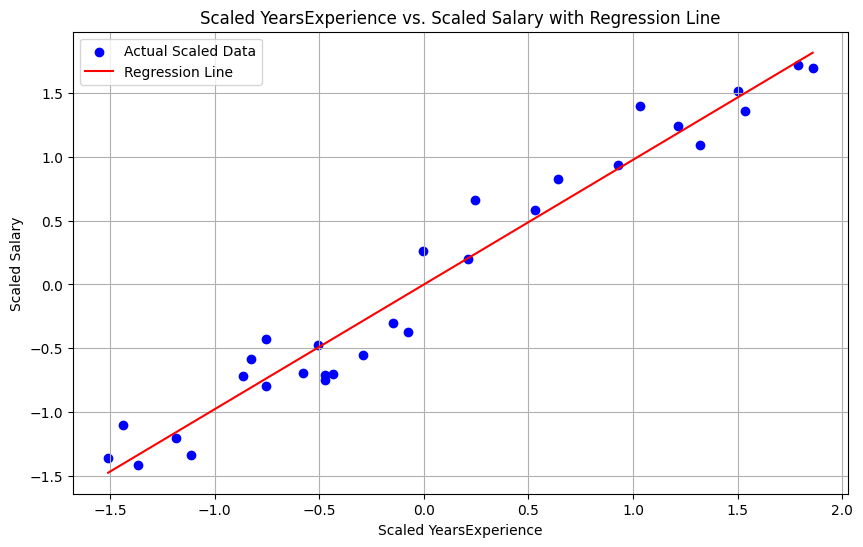

Plotting scaled data points and regression line.


In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_scaled, y_scaled, color='blue', label='Actual Scaled Data')
plt.plot(X_scaled, y_pred_final_scaled, color='red', label='Regression Line')
plt.title('Scaled YearsExperience vs. Scaled Salary with Regression Line')
plt.xlabel('Scaled YearsExperience')
plt.ylabel('Scaled Salary')
plt.legend()
plt.grid(True)
plt.show()

print("Plotting scaled data points and regression line.")

## Interpret the Results


### Interpretation of Results

**Final Mean Squared Error (MSE):**
The final MSE achieved by the model after 1000 epochs of gradient descent is **0.0430**. Since the data was scaled, an MSE close to 0 indicates a good fit. This relatively low value suggests that the model's predictions (`y_pred_final_scaled`) are, on average, close to the actual scaled salary values (`y_scaled`).

**Visual Fit of the Regression Line:**
The plot of 'Scaled YearsExperience' vs. 'Scaled Salary' with the regression line clearly shows a strong positive linear relationship. The red regression line closely follows the general trend of the blue actual data points, indicating that our linear model has successfully captured the underlying relationship between years of experience and salary in the scaled dataset. The points are not perfectly on the line, which is expected in real-world data, but the overall fit is excellent.

**Optimized Slope (m) and Intercept (b):**
*   **Slope (m):** The final optimized slope `m` is approximately **0.9782**. Since both 'YearsExperience' and 'Salary' were standardized (scaled), this positive slope indicates a strong positive correlation. For every one standard deviation increase in 'YearsExperience', the 'Salary' is predicted to increase by approximately 0.9782 standard deviations. This implies that as years of experience increase, salary tends to increase significantly.
*   **Intercept (b):** The final optimized intercept `b` is approximately **-0.0000** (very close to zero). In a scaled dataset where both independent and dependent variables have been standardized to have a mean of 0, the intercept represents the predicted scaled salary when the scaled years of experience are zero. A value near zero is expected when variables are centered, as it implies that the regression line passes very close to the origin (mean of scaled data points).